In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import json, os, joblib, math, ast
from itertools import product
from Metrics.Plotter.index import Plotter 

# COMPARAÇÃO DE MODELOS

In [2]:
indexes = sorted([int(path.split('_')[-1]) for path in os.listdir('Backup')])
df      = []

for index in indexes:
    path = os.path.join('Backup', f'model_{index}/info.json')
    
    with open(path, 'r', encoding='utf-8') as file:
        data = json.loads(file.read())
    
    folder = data.get('folder')
    name   = data.get('model')
    data = data['info']
    data['name'] = name
    data['id']   = index
    data['folder'] = folder
    df.append(data)


df = pd.DataFrame(df)
df

,accuracy,precision,recall,auc,name,id,folder
0,0.972854,0.973183,0.972854,0.997389,random_forest,1,model_1


In [3]:
df.sort_values(by='auc', ascending=False)

,accuracy,precision,recall,auc,name,id,folder
0,0.972854,0.973183,0.972854,0.997389,random_forest,1,model_1


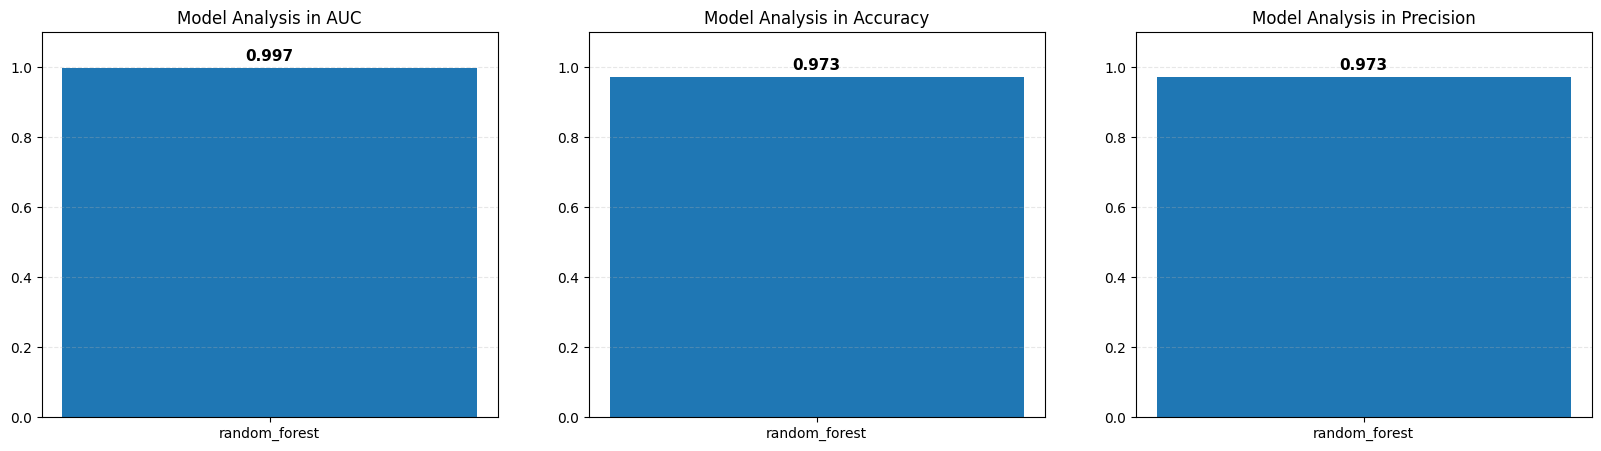

In [4]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
Plotter({key: value for key, value in zip(df.name, df.auc)}, title='Model Analysis in AUC')

plt.subplot(1, 3, 2)
Plotter({key: value for key, value in zip(df.name, df.accuracy)}, title='Model Analysis in Accuracy')

plt.subplot(1, 3, 3)
Plotter({key: value for key, value in zip(df.name, df.precision)}, title='Model Analysis in Precision')
plt.show()

# SELECIONANDO MODELO

In [5]:
#target = df.loc[df.name == 'logistic_regression'].sort_values(by='auc',ascending=False).iloc[0]
#target = df.loc[df.auc == df.auc.max()].iloc[0]
target = df.iloc[-1]

target.to_frame().T

,accuracy,precision,recall,auc,name,id,folder
0,0.972854,0.973183,0.972854,0.997389,random_forest,1,model_1


In [6]:
def loadModel(id):
    with open(f'Backup/model_{id}/info.json', 'r', encoding='utf-8') as file:
        data = json.loads(file.read())

    data['model'] = joblib.load(f'Backup/model_{id}/model.pkl')
    return data


id   = target.id
data = loadModel(id)
data.get('info')

{'accuracy': 0.9728543285,
 'precision': 0.9731833176,
 'recall': 0.9728543285,
 'auc': 0.9973890598}

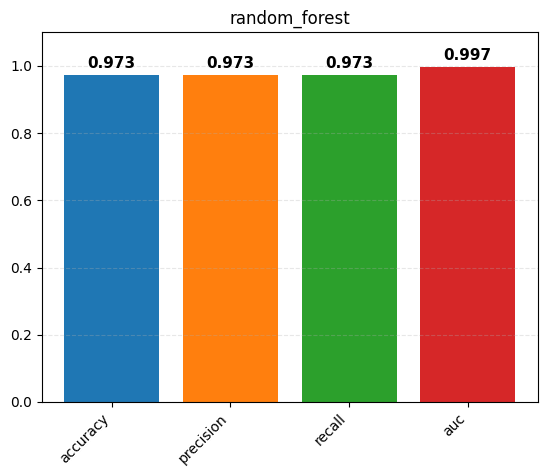

In [7]:
name = target['name']
del target['name'], target['id'], target['folder']
Plotter(target.to_dict(), title=name)

In [8]:
variables = data['variables']
model     = data['model']
model

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2


# CARREGANDO DADOS

In [9]:
df = pd.read_csv('../../Dataset/model.csv')
df['data'] = df.data.apply(ast.literal_eval)
df.head(3)

,decay,mean_diff,min,mean,median,last,std,rise,amplitude,max_diff,min_diff,max,first_diff,median_diff,std_diff,alcohol,data
0,284,-0.382979,23250,23557.723404,23281.0,23275,750.506487,-2682,2966,1341.0,-1006.5,26216,479.0,-2.0,334.276298,False,"[23534, 24013, 26216, 26172, 26108, 25037, 240..."
1,261,-0.361702,23536,23877.446809,23585.0,23596,756.473851,-2346,2607,1168.5,-858.5,26143,367.0,0.5,297.088420,False,"[23797, 24164, 26134, 26143, 26142, 26120, 253..."
2,204,8.680851,23695,24055.574468,23765.0,23801,757.619921,-2460,2664,1175.0,-862.0,26359,1006.0,2.0,312.737500,False,"[23899, 24905, 26249, 26359, 26335, 26225, 254..."


In [10]:
data['thresholds']

[{'class': False, 'treshold': 0.5566666667}, {'class': True, 'treshold': 0.75}]

In [11]:
model.classes_

array([False,  True])

In [12]:
variables = data['variables']
yProba    = model.predict_proba(df[variables])[:, 1]
MIN_TRESH = data['thresholds'][1]['treshold']
print(MIN_TRESH)

df['result'] = np.where(yProba > MIN_TRESH, model.classes_[1], model.classes_[0])
df[['result', 'alcohol']].head(10)

0.75


,result,alcohol
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
5,False,False
6,False,False
7,False,False
8,False,False
9,False,False


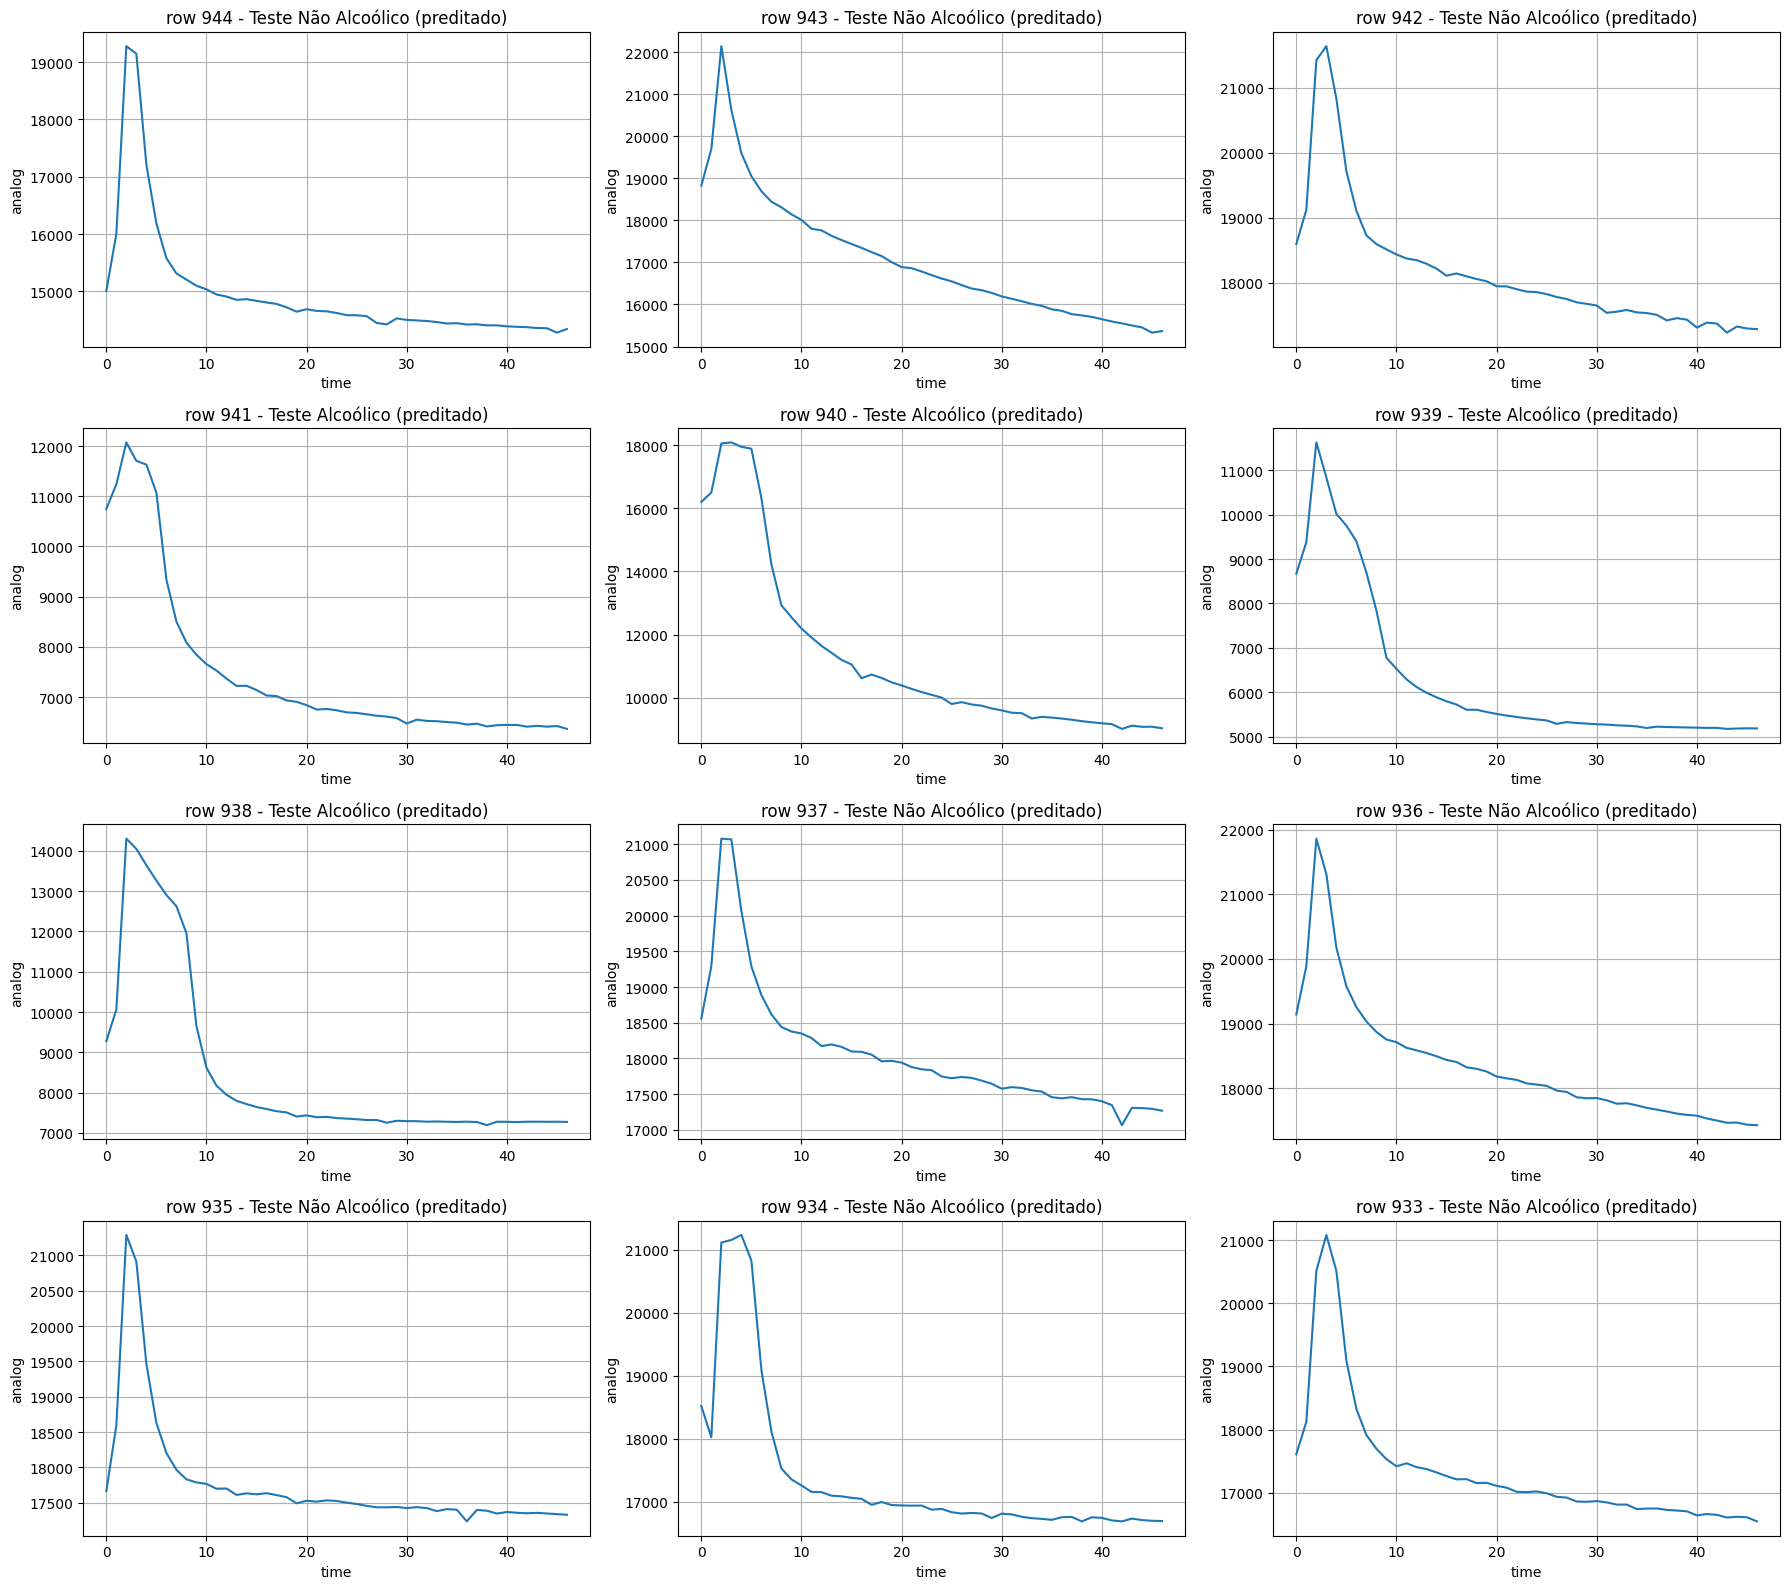

In [13]:
def plotTables(df, limit=None):
    count = len(df) if limit is None else min(limit, len(df))
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for idx, (i, row) in enumerate(df.iterrows()):
        if idx >= count:
            break

        plt.subplot(numRows, numCols, idx + 1)
        plt.plot(row.data)
        title  = f'row {i+2} - Teste {"Alcoólico" if row["alcohol"] else "Não Alcoólico"}'
        status = f'({"preditado" if row.alcohol == row.result else "divergente"})'
        
        plt.title(f'{title} {status}')
        plt.grid(), plt.xlabel('time'), plt.ylabel('analog')

    plt.tight_layout()
    plt.show()


plotTables(df.iloc[::-1], limit=12)

1 dados divergentes


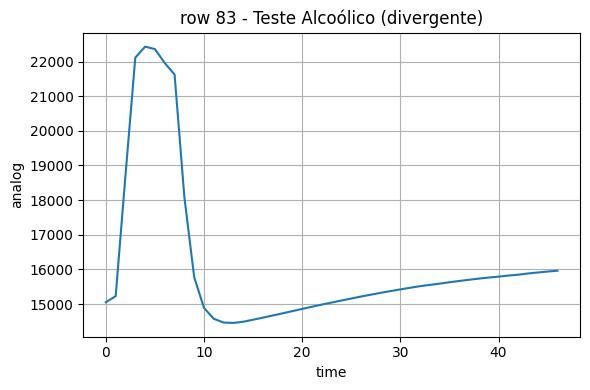

In [14]:
target = df.loc[df.alcohol != df.result].iloc[::-1]
print(f'{len(target)} dados divergentes')

if len(target) > 0:
    plotTables(target, limit=None)

# SISTEMA EMBARCADO

In [15]:
from pyperclip import copy

In [16]:
print(', '.join(variables) + ';')

decay, mean_diff, min, mean, median, last, std, rise, amplitude, max_diff, min_diff, max, first_diff, median_diff, std_diff;


In [17]:
scaler    = model.named_steps.get('scaler')
predictor = model.named_steps.get('model')

OFFSET  = scaler.mean_
GAIN    = 1.0 / scaler.scale_

### CÓDIGO PARA LOGISTIC REGRESSION

In [18]:
1/0

WEIGHTS = predictor.coef_[0]
BIAS    = float(predictor.intercept_[0])

text = f"""
bool get(){{
    static const int size     = {len(OFFSET)};
    const float OFFSET[size]  = {{ {", ".join(map(str, OFFSET))} }};
    const float GAIN[size]    = {{ {", ".join(map(str, GAIN))}   }};
    const float WEIGHTS[size] = {{ {", ".join(map(str, predictor.coef_[0]))} }};
    const float BIAS       = {str(BIAS)};
    const float BEST_TRESH = {str(MIN_TRESH)};

    float z = BIAS;
    float x[size];
    int index = 0;

"""

for i, column in enumerate(variables):
    text += f'    x[index++] = (float) {column};\n'

text += """
    for(int i=0; i<size; i++)
        z += WEIGHTS[i] * (x[i] - OFFSET[i]) * GAIN[i];

    const float prob = 1.0f / (1.0f + expf(-z));
    return (prob > BEST_TRESH);
}
"""

print(text)
copy(text)

ZeroDivisionError: division by zero

### CÓDIGO PARA RANDOM FOREST

In [19]:
features_list = []
values_list   = []
left_list  = []
right_list = []
tree_roots = []
current_index = 0

for tree in predictor.estimators_:
    tree_roots.append(current_index)
    
    left = tree.tree_.children_left
    right = tree.tree_.children_right
    threshold = tree.tree_.threshold
    features = tree.tree_.feature
    value = tree.tree_.value
    
    n_nodes = tree.tree_.node_count
    
    for i in range(n_nodes):
        if left[i] != right[i]: # Nó de decisão
            features_list.append(features[i])
            values_list.append(threshold[i])
            left_list.append(current_index + left[i])
            right_list.append(current_index + right[i])
        else: # Nó folha
            features_list.append(-1) # -1 indica que é folha
            val = value[i][0]
            prob = val[1] / sum(val)
            values_list.append(prob)
            left_list.append(-1)
            right_list.append(-1)
            
    current_index += n_nodes

n_estimators = len(predictor.estimators_)


c_code = f"""
#ifndef RF_MODEL_DATA_H
#define RF_MODEL_DATA_H

#include <stdint.h>

static const int NUM_TREES = {n_estimators};
static const int TOTAL_NODES = {current_index};

// Arrays armazenados na Flash do ESP32
static const int32_t tree_roots[NUM_TREES] = {{ {', '.join(map(str, tree_roots))} }};
static const int8_t  features[TOTAL_NODES] = {{ {', '.join(map(str, features_list))} }};
static const float   values[TOTAL_NODES]   = {{ {', '.join(map(lambda x: f"{x:.5f}", values_list))} }};
static const int32_t left_child[TOTAL_NODES] = {{ {', '.join(map(str, left_list))} }};
static const int32_t right_child[TOTAL_NODES] = {{ {', '.join(map(str, right_list))} }};

inline float evaluate_rf(const float* x) {{
    float prob_sum = 0.0f;
    for (int i = 0; i < NUM_TREES; i++) {{
        int32_t node = tree_roots[i];
        while (features[node] != -1) {{ // Enquanto não for folha
            if (x[features[node]] <= values[node]) {{
                node = left_child[node];
            }} else {{
                node = right_child[node];
            }}
        }}
        prob_sum += values[node];
    }}
    return prob_sum / (float)NUM_TREES;
}}

#endif // RF_MODEL_DATA_H
"""

# Salvando as matrizes no arquivo .h
with open('rf_model_data.h', 'w', encoding='utf-8') as f:
    f.write(c_code)

print(f"Sucesso! Código gerado com {current_index} nós.")
print(f"Tamanho estimado dos arrays na Flash do ESP32: {(current_index * 13)/1024:.1f} KB\n")

text = f"""
bool get(){{
    static const int size     = {len(OFFSET)};
    const float OFFSET[size]  = {{ {", ".join(map(str, OFFSET))} }};
    const float GAIN[size]    = {{ {", ".join(map(str, GAIN))}   }};
    const float BEST_TRESH    = {str(MIN_TRESH)};

    float x[size];
    int index = 0;

"""

for i, column in enumerate(variables):
    text += f'    x[index++] = (float) {column};\n'

text += """
    for(int i=0; i<size; i++)
        x[i] = (x[i] - OFFSET[i]) * GAIN[i];

    float final_prob = evaluate_rf(x); 
    return (final_prob > BEST_TRESH);
}
"""

copy(text)
print(text)

Sucesso! Código gerado com 21674 nós.
Tamanho estimado dos arrays na Flash do ESP32: 275.2 KB


bool get(){
    static const int size     = 15;
    const float OFFSET[size]  = { 2926.1972428419936, -31.90167189368471, 15046.71474019088, 16463.16017237878, 16079.6065747614, 16221.103923647932, 1425.9941473502106, -2886.513255567338, 5812.710498409332, 1471.7322375397666, -1727.515906680806, 20859.42523860021, 494.14316012725345, 8.390243902439025, 496.85785993027406 };
    const float GAIN[size]    = { 0.0002773060324472669, 0.012014642567794866, 0.0001955892268326754, 0.00020702317070215044, 0.00019826256093175728, 0.0001943961108104313, 0.0011728367686797444, 0.00044986892676563436, 0.00032940185238441213, 0.0009322204100065247, 0.0008005319338741509, 0.00024482176746804305, 0.0006448348230546723, 0.02703574679182674, 0.0040802234452702   };
    const float BEST_TRESH    = 0.75;

    float x[size];
    int index = 0;

    x[index++] = (float) decay;
    x[index++] = (float) mean_diff;